# ML Tutorial: Gradient Boosting
## Focus: How Learning Rate and Number of Trees Affect Performance
### Real-world example: Apple stock movement prediction with **XGBoost**

# **1. Import the required libraries**

You will use Python libraries for data handling, visualisation, stock-market data collection, model training, and evaluation.

### **Tasks**

The required libraries include **pandas** and **NumPy** for data manipulation, **Matplotlib** for visualisation, **yfinance** for downloading stock data, **XGBoost** for **Gradient** **Boosting** classification, and **scikit-learn** for splitting the dataset and evaluating performance.

The main libraries used are:

pandas
numpy
matplotlib.pyplot
yfinance
xgboost
sklearn.model_selection
sklearn.metrics

In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
!pip install yfinance xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# **2. Load and inspect stock data**

You are given historical stock price data for a company such as **Apple Inc**. The dataset contains daily market values including opening price, closing price, highest price, lowest price, and trading volume.

### **Tasks**

The dataset is loaded by downloading stock data from **Yahoo Finance** over a selected time period. The first few rows are displayed to inspect the structure of the data and confirm that it has been loaded correctly.

In [2]:
# =========================
# 2. LOAD DATA
# =========================
data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

data.head()

/tmp/ipykernel_10038/1922952832.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928032,72.533072,71.708672,72.277555,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


# 3. Perform feature engineering

Raw stock prices are not always suitable as direct inputs to a machine-learning model. Additional features must be created to capture useful patterns.

## **Tasks**

New features are created by computing daily returns using percentage change, calculating 5-day and 10-day moving averages, and measuring volatility using the rolling standard deviation of returns. A target variable is also created to represent whether the next day’s closing price is higher than today’s closing price. After creating these features, rows with missing values are removed.

In [3]:
# =========================
# 3. FEATURE ENGINEERING
# =========================
data['Return'] = data['Close'].pct_change()
data['MA5'] = data['Close'].rolling(5).mean()
data['MA10'] = data['Close'].rolling(10).mean()
data['Volatility'] = data['Return'].rolling(5).std()
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)
data = data.dropna()
data.head()

Price,Close,High,Low,Open,Volume,Return,MA5,MA10,Volatility,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2020-01-15,75.049690,76.052475,74.618202,75.172630,121923600,-0.004285,75.254109,73.764877,0.015547,1
2020-01-16,75.989799,76.100690,75.230481,75.592062,108829200,0.012526,75.524570,74.123805,0.013709,1
2020-01-17,76.831085,76.833491,75.931952,76.238088,137816400,0.011071,75.929543,74.637251,0.014044,0
2020-01-21,76.310425,76.901002,76.173022,76.459877,110843200,-0.006777,75.910739,75.041501,0.011467,1
2020-01-22,76.582794,77.134802,76.488780,76.794915,101832400,0.003569,76.152759,75.506977,0.008727,1


In [4]:
# =========================
# 4. TRAIN TEST SPLIT (TIME SERIES SAFE)
# =========================
features = ['Return', 'MA5', 'MA10', 'Volatility']
X = data[features]
y = data['Target']

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [5]:
# =========================
# 5. BASELINE MODEL
# =========================
baseline = (data['Return'] > 0).astype(int).shift(1).dropna()
baseline_acc = accuracy_score(y_test[1:], baseline.loc[y_test.index[1:]])
print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.4120603015075377


# **4. Train the Gradient Boosting model**

Gradient Boosting combines many weak decision trees into one strong predictive model. In this tutorial, the XGBoost implementation is used.

## **Tasks**

The model is trained by creating an **XGBClassifier** and selecting appropriate hyperparameters such as the number of trees, learning rate, maximum tree depth, and subsampling ratio. The model is then fitted on the training data.

In [6]:
# =========================
# 6. TRAIN MAIN MODEL
# =========================
model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

# **4. Evaluate the model**
The model's ability to generalize should be assessed using untested data after training.

## **Tasks**

In order to assess the trained model, predictions are made using the test data, accuracy is calculated, and a classification report with **precision**, **recall**, and **F1-score** is generated. A more comprehensive picture of model performance is offered by these metrics than by accuracy alone.

In [7]:
predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.55
              precision    recall  f1-score   support

           0       0.51      0.76      0.61        92
           1       0.65      0.37      0.47       108

    accuracy                           0.55       200
   macro avg       0.58      0.57      0.54       200
weighted avg       0.58      0.55      0.53       200



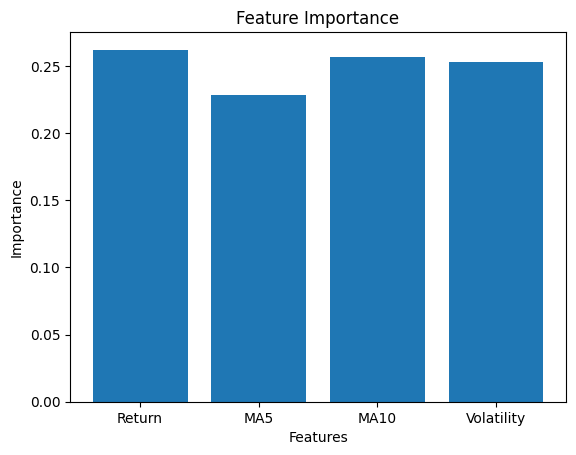

In [8]:
# =========================
# 7. FEATURE IMPORTANCE
# =========================
importances = model.feature_importances_

plt.figure()
plt.bar(features, importances)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

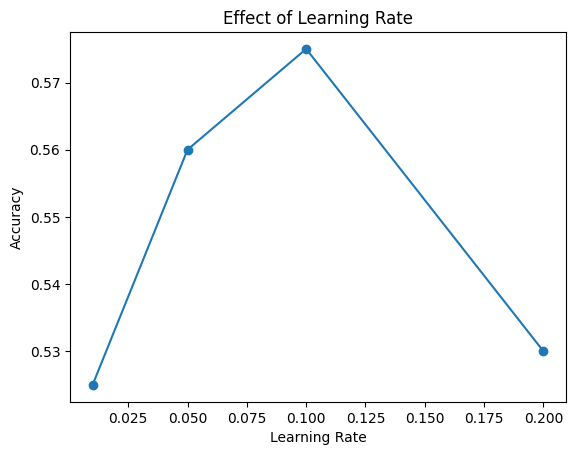

In [9]:
# =========================
# 8. LEARNING RATE EXPERIMENT
# =========================
learning_rates = [0.01, 0.05, 0.1, 0.2]
results = []

for lr in learning_rates:
    model = XGBClassifier(
        n_estimators=200,
        learning_rate=lr,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append(acc)

plt.figure()
plt.plot(learning_rates, results, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Effect of Learning Rate")
plt.show()


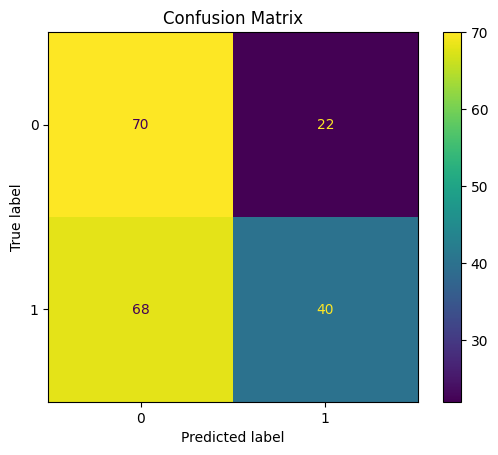

In [10]:
# =========================
# 9. CONFUSION MATRIX
# =========================
ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("Confusion Matrix")
plt.show()

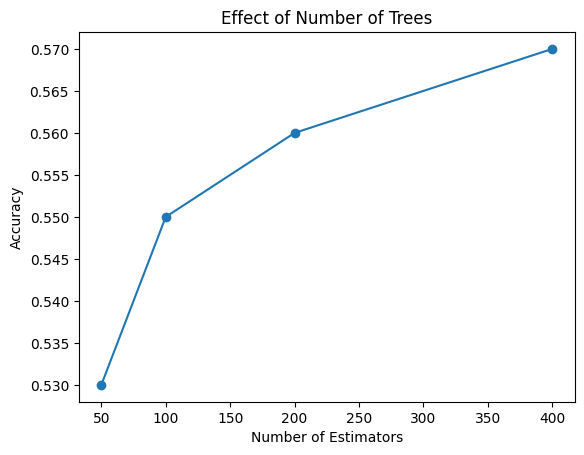

In [11]:
# =========================
# 10. ESTIMATOR EXPERIMENT
# =========================
estimators = [50, 100, 200, 400]
results_est = []

for n in estimators:
    model = XGBClassifier(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results_est.append(acc)

plt.figure()
plt.plot(estimators, results_est, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Effect of Number of Trees")
plt.show()


In [12]:
# =========================
# 10. NUMBER OF TREES EXPERIMENT
# =========================
estimators = [50, 100, 200, 400]
est_results = []

for n in estimators:
    model = XGBClassifier(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    est_results.append(acc)

est_df = pd.DataFrame({
    "Number of Trees": estimators,
    "Accuracy": est_results
})

print(est_df)

   Number of Trees  Accuracy
0               50     0.540
1              100     0.575
2              200     0.560
3              400     0.570


https://github.com/VineethDoddaballapuraRaju24089093/ml_assinment